In [2]:
import os,json,cortex
import numpy as np
from config.dir import DATA_DIR ,RESULTS_DATA_DIR
from sklearn.preprocessing import StandardScaler
from himalaya.kernel_ridge import KernelRidgeCV
from himalaya.backend import set_backend
from sklearn.pipeline import make_pipeline
from voxelwise_tutorials.utils import generate_leave_one_run_out
from sklearn.model_selection import check_cv
import matplotlib.pyplot as plt
from utils.npp import zscore

# Using subjects 3 & 1  for 9-12 session as a training 

In [2]:
def open_json(subj,file):
    
    dir=os.path.join( RESULTS_DATA_DIR,subj)
    with open(os.path.join(dir,file), "r")  as f:
        data = json.load(f)
    return  np.array(data, dtype=float)

# Features using S3 & S1 fmri response for training & S3 predicted values for testing

In [3]:
subject_1 = 'sub-UTS01'
subject_2 = 'sub-UTS02'
subject_3 = 'sub-UTS03'

X_train = open_json(subject_1,'fmri_train.json')
X_test = zscore(np.load(os.path.join(RESULTS_DATA_DIR,subject_1,'test_predict.npy')) )

print("(n_samples_train, n_features) =", X_train.shape)
print("(n_samples_test, n_features) =", X_test.shape)

(n_samples_train, n_features) = (11414, 81126)
(n_samples_test, n_features) = (291, 81126)


In [4]:
X_train_3 = open_json(subject_3,'fmri_train.json')
X_test_3 = zscore(np.load(os.path.join(RESULTS_DATA_DIR,subject_3,'test_predict.npy')) )
print("(n_samples_train, n_features) =", X_train_3.shape)
print("(n_samples_test, n_features) =", X_test_3.shape)

(n_samples_train, n_features) = (11414, 95556)
(n_samples_test, n_features) = (291, 95556)


# Selecting top 10k voxels for training

In [5]:
scores_train = np.load(os.path.join(RESULTS_DATA_DIR,subject_1,'scores_train.npy'))
scores_train_3 = np.load(os.path.join(RESULTS_DATA_DIR,subject_3,'scores_train.npy'))

In [6]:
best_voxels = np.argsort(scores_train)[::-1][:10000]
best_voxels_3 = np.argsort(scores_train_3)[::-1][:10000]

In [7]:
X_train_best = X_train[:, best_voxels]
X_test_best = X_test[:, best_voxels]
print("(n_samples_train, n_features) =", X_train_best.shape)
print("(n_samples_test, n_features) =", X_test_best.shape)

(n_samples_train, n_features) = (11414, 10000)
(n_samples_test, n_features) = (291, 10000)


In [8]:
X_train_best_3 = X_train_3[:, best_voxels_3]
X_test_best_3 = X_test_3[:, best_voxels_3]
print("(n_samples_train, n_features) =", X_train_best_3.shape)
print("(n_samples_test, n_features) =", X_test_best_3.shape)

(n_samples_train, n_features) = (11414, 10000)
(n_samples_test, n_features) = (291, 10000)


# Subject 2 fmri for testing & training 

In [9]:
Y_train = open_json(subject_2,'fmri_train.json')
Y_test= zscore(open_json(subject_2,'fmri_test.json'))

print("(n_samples_train, n_voxels) =", Y_train.shape)
print("( n_samples_test, n_voxels) =", Y_test.shape)

(n_samples_train, n_voxels) = (11414, 94251)
( n_samples_test, n_voxels) = (291, 94251)


## checking Standard deviation and mean for Features and fmri

In [10]:
X_train_concat = np.concatenate([X_train_best, X_train_best_3], axis=0)
X_test_concat = np.concatenate([X_test_best, X_test_best_3], axis=0)
print("Mean of features(train):",np.mean(X_train_concat))
print("Standard deviation of features(train): ",np.std(X_train_concat))
print("Mean of features(test) :",np.mean(X_test_concat))
print("Standard deviation of features(test): ",np.std(X_test_concat))

Mean of features(train): 1.441304486736845e-17
Standard deviation of features(train):  1.0
Mean of features(test) : 1.9396473736062871e-19
Standard deviation of features(test):  1.0


In [11]:
Y_train_concat = np.concatenate([Y_train, Y_train], axis=0)
Y_test_concat = np.concatenate([Y_test, Y_test], axis=0)
print("Mean of fmri(train):",np.mean(Y_train_concat))
print("Standard deviation of fmri(train):",np.std(Y_train_concat))
print("Mean of fmri(train):",np.mean(Y_test_concat))
print("Standard deviation of fmri(train):",np.std(Y_test_concat))

Mean of fmri(train): 9.739324083624831e-19
Standard deviation of fmri(train): 1.0
Mean of fmri(train): 2.1222727203225243e-18
Standard deviation of fmri(train): 1.0


In [12]:
print("Mean of fmri(train):",np.mean(Y_train))
print("Standard deviation of fmri(train):",np.std(Y_train))
print("Mean of fmri(train):",np.mean(Y_test))
print("Standard deviation of fmri(train):",np.std(Y_test))

Mean of fmri(train): 1.163308154432966e-18
Standard deviation of fmri(train): 1.0
Mean of fmri(train): 3.1834090804837863e-18
Standard deviation of fmri(train): 1.0


# Create run onset

In [13]:
run_onsets= open_json(subject_1,'run_on_1_3.json').tolist()
run_onsets=list(map(int, run_onsets))
len(run_onsets)

65

In [14]:
n_samples_train = X_train_concat.shape[0]
cv = generate_leave_one_run_out(n_samples_train, run_onsets)
cv = check_cv(cv)  # copy the cross-validation splitter into a reusable list
X_train_= X_train_concat.astype("float32")
alphas = np.logspace(1, 20, 20)

# Create training model pipline 

In [15]:
pipeline = make_pipeline(
    StandardScaler(with_mean=True, with_std=False),
    KernelRidgeCV(
        alphas=alphas, cv=cv, Y_in_cpu=True,
        
        solver_params=dict(n_targets_batch=500, n_alphas_batch=5,
                           n_targets_batch_refit=100)
    ),
)

In [16]:
backend = set_backend("torch_cuda", on_error="warn")
print(backend)

<module 'himalaya.backend.torch_cuda' from '/home/ckj24/miniforge-pypy3/envs/fmri-algo/lib/python3.13/site-packages/himalaya/backend/torch_cuda.py'>


In [17]:
import torch
import gc
#del pipeline
#del alphas
#del backend 
torch.cuda.empty_cache()
gc.collect()

20

In [18]:
_ = pipeline.fit(X_train_concat.astype("float32"), Y_train_concat.astype("float32"))

/home/ckj24/miniforge-pypy3/envs/fmri-algo/lib/python3.13/site-packages/himalaya/kernel_ridge/_sklearn_api.py:490: UserWarning: Solving linear kernel ridge is slower than solving ridge when n_samples > n_features (here 22828 > 10000). Using himalaya.ridge.RidgeCV would be faster. Use warn=False to silence this warning.
  warnings.warn(


# Scores of training and testing data set

In [19]:
scores_train = pipeline.score(X_train_concat,Y_train_concat)
print("(n_voxels train,) =", scores_train.shape)
scores_test = pipeline.score(X_test_concat, Y_test_concat)
print("(n_voxels test,) =", scores_test.shape)

(n_voxels train,) = torch.Size([94251])
(n_voxels test,) = torch.Size([94251])


Text(0.5, 0, 'R-squared')

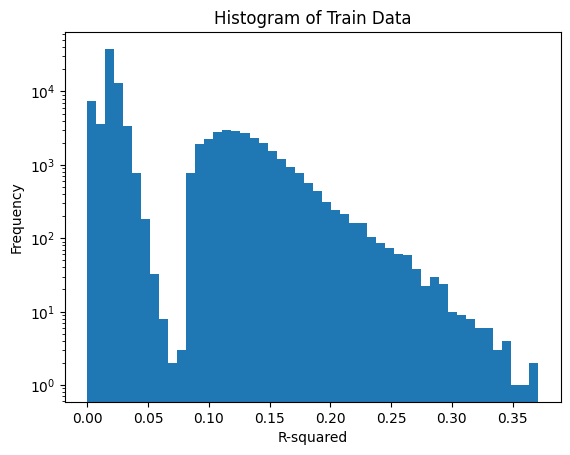

In [20]:
plt.hist(scores_train.cpu().numpy(), bins=50, log=True)
plt.title("Histogram of Train Data")
plt.ylabel("Frequency")
plt.xlabel("R-squared")

Text(0.5, 0, 'R-squared')

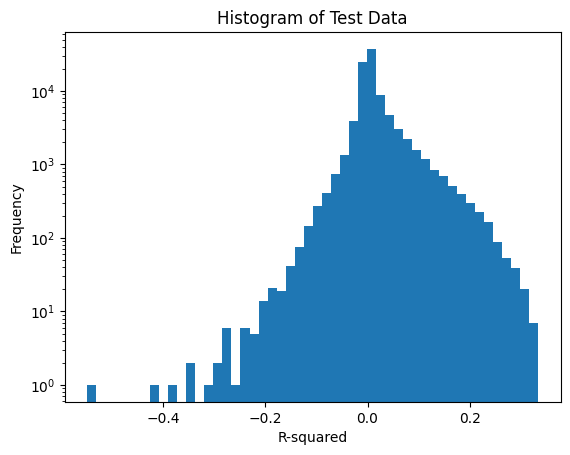

In [21]:
plt.hist(scores_test.cpu().numpy(), bins=50, log=True)
plt.title("Histogram of Test Data")
plt.ylabel("Frequency")
plt.xlabel("R-squared")

In [22]:
print("r-squared_average train =", np.mean(scores_train.cpu().numpy()).round(4))
print("r-squared_average =", np.mean(scores_test.cpu().numpy()).round(4))

r-squared_average train = 0.0523
r-squared_average = 0.0136


# Save trained data 

In [32]:
#np.savetxt('train.txt', scores_train.cpu().numpy())
#scores_train = np.loadtxt('train.txt', dtype=float)
np.save(os.path.join(RESULTS_DATA_DIR,subject_2,'scores_train_transfor_1_3_10k'), scores_train.cpu().numpy())
np.save(os.path.join(RESULTS_DATA_DIR,subject_2,'scores_test_transfor_1_3_10k'), scores_test.cpu().numpy())
#scores_test = np.load(os.path.join(RESULTS_DATA_DIR,subject_2,'scores_test_transform.npy'))

In [34]:
subject = 'sub-UTS02'
train_predict=pipeline.predict(X_train_concat)
test_predict=pipeline.predict(X_test_concat)
np.save(os.path.join(RESULTS_DATA_DIR,subject,'train_predict_transfor_1_3_10k'), train_predict.cpu().numpy())
np.save(os.path.join(RESULTS_DATA_DIR,subject,'test_predict_transfor_1_3_10k'), test_predict.cpu().numpy())

# plotting on pycortex

In [6]:
def set_pycortex_store(filestore):
    """Set the pycortex store to the specified directory."""
    cortex.database.default_filestore = filestore
    cortex.db.filestore = filestore
    cortex.db.reload_subjects()
    print(f"pycortex store set to {filestore}")


In [7]:
set_pycortex_store(os.path.join(DATA_DIR, 'ds003020/derivative/pycortex-db'))

pycortex store set to /home/ckj24/genevieve/ds003020/derivative/pycortex-db


# Training Data Subject 2

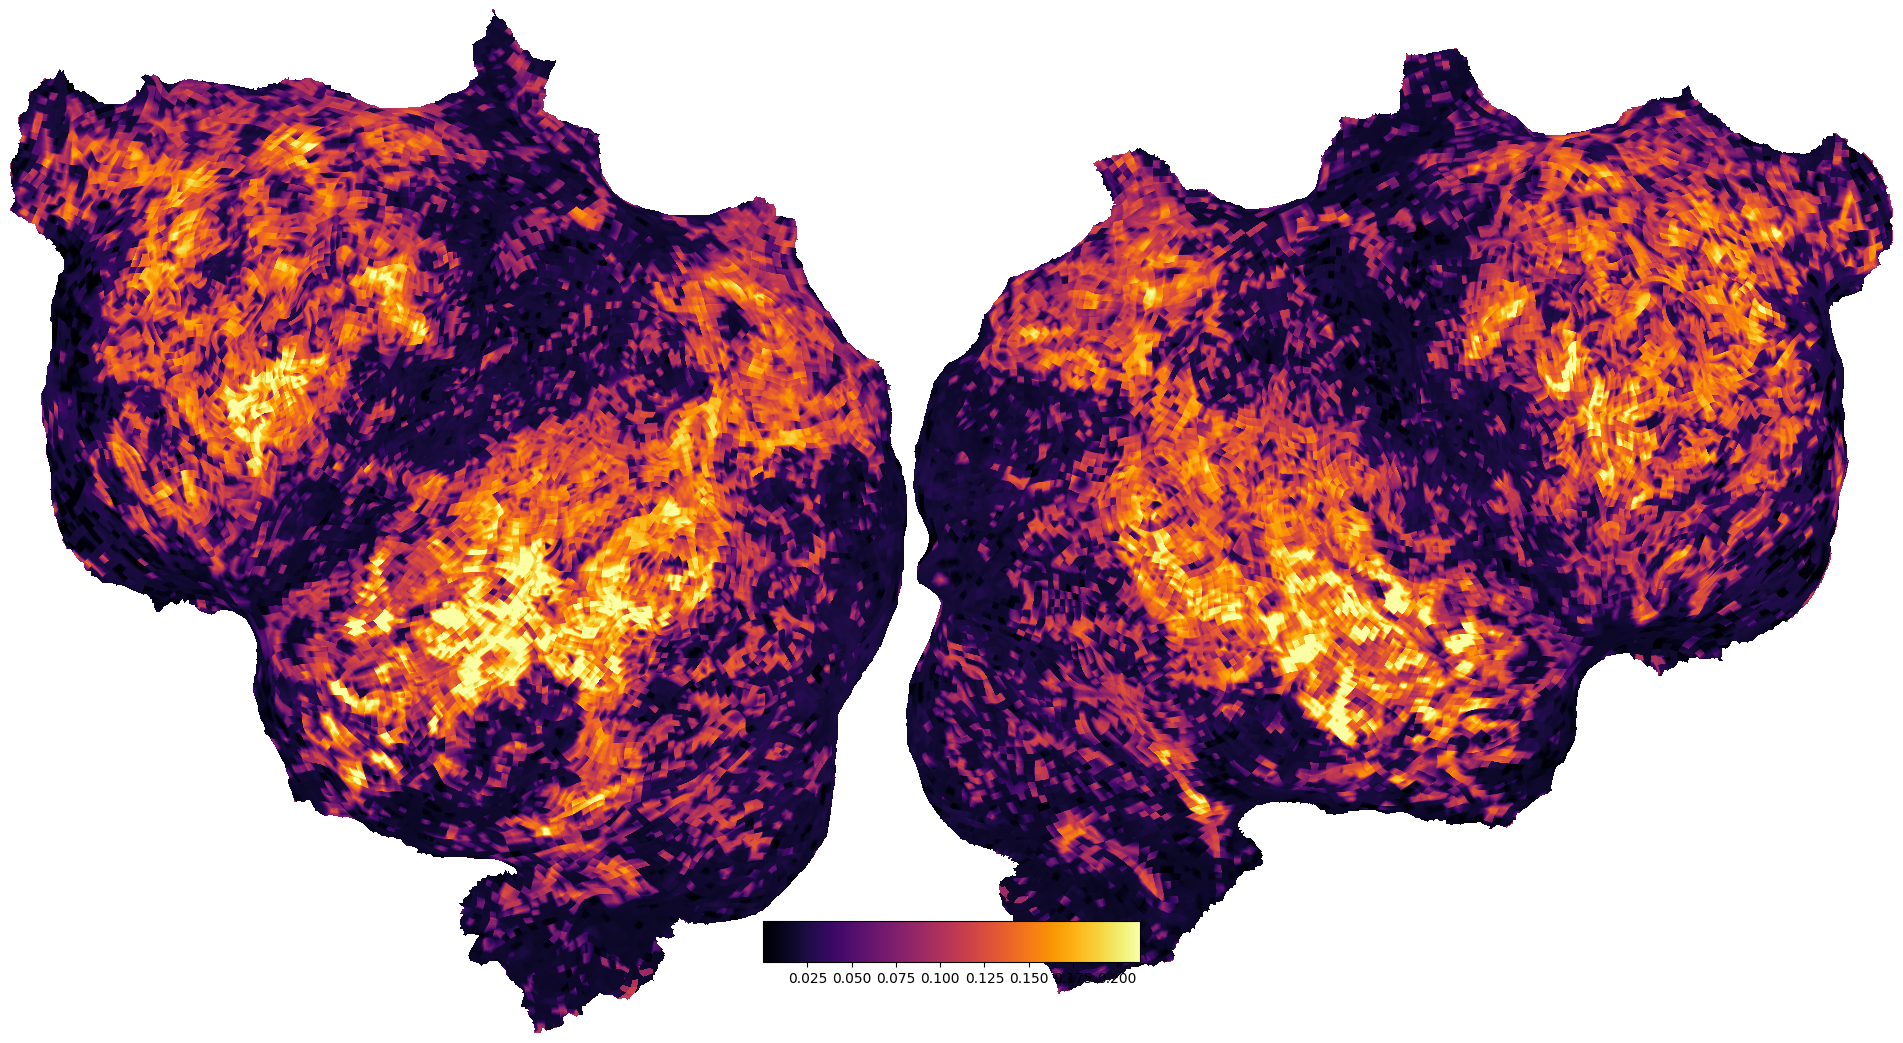

In [25]:
subject = 'UTS02'
xfm = 'UTS02_auto'

# First create example voxel data for this subject and transform
voxel_data = scores_train.cpu().numpy()
voxel_vol = cortex.Volume(voxel_data, subject, xfm,cmap="inferno")

# Then we have to get a mapper from voxels to vertices for this transform
mapper = cortex.get_mapper(subject, xfm, 'line_nearest', recache=True)

# Just pass the voxel data through the mapper to get vertex data
vertex_map = mapper(voxel_vol)

# You can plot both as you would normally plot Volume and Vertex data
cortex.quickshow(voxel_vol, with_rois=False)
plt.show()

# Testing Data for S2 

Caching mapper...


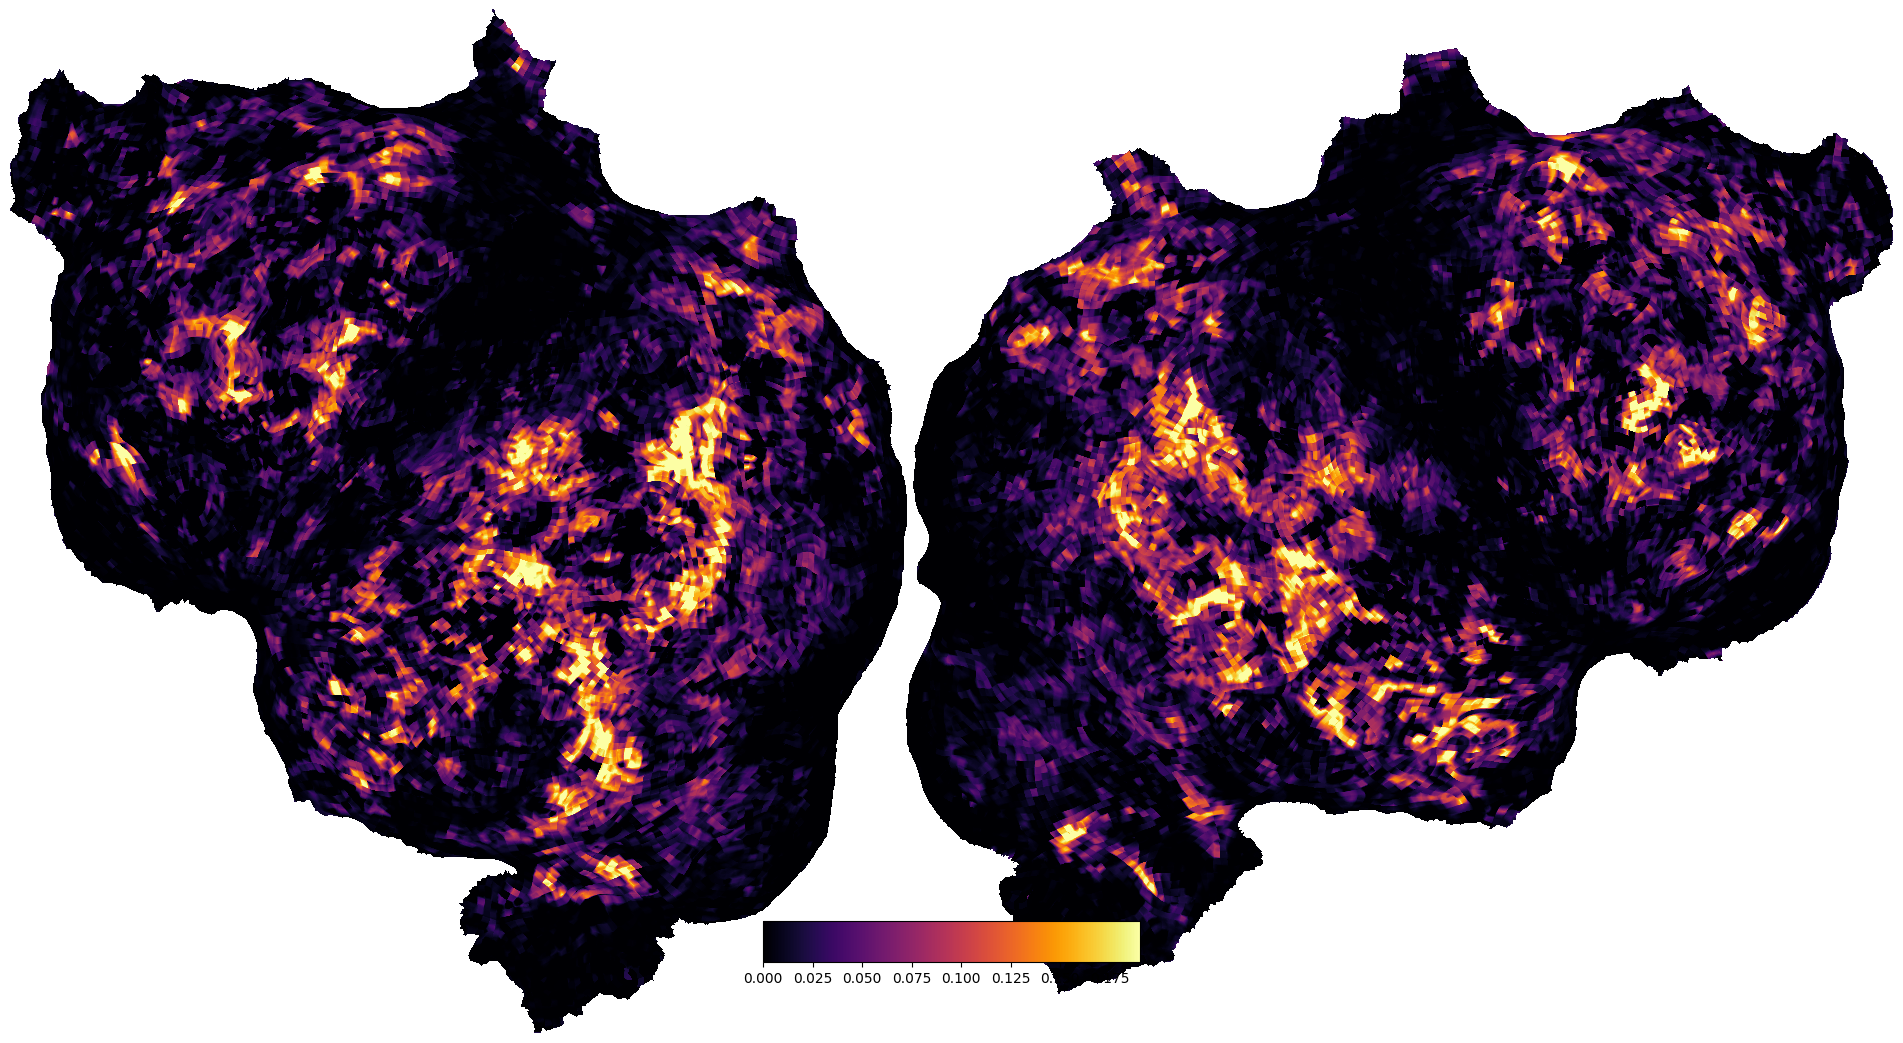

In [26]:
# First create example voxel data for this subject and transform
voxel_data = scores_test.cpu().numpy()
voxel_vol = cortex.Volume(voxel_data, subject, xfm,vmin=0,cmap="inferno")

# Then we have to get a mapper from voxels to vertices for this transform
mapper = cortex.get_mapper(subject, xfm,  recache=True)

# Just pass the voxel data through the mapper to get vertex data
vertex_map = mapper(voxel_vol)

# You can plot both as you would normally plot Volume and Vertex data
cortex.quickshow(voxel_vol, with_rois=False)
plt.show()

<Axes: xlabel='log10(alpha)', ylabel='Number of targets'>

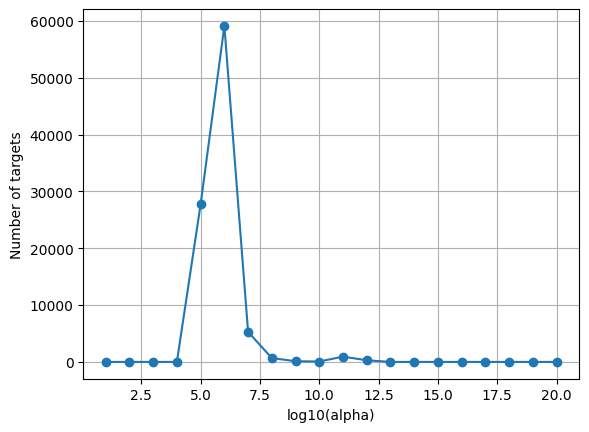

In [27]:
from himalaya.viz import plot_alphas_diagnostic
best_alphas = backend.to_numpy(pipeline[-1].best_alphas_)
plot_alphas_diagnostic(best_alphas=best_alphas, alphas=alphas)
#plt.show()

# Load baseline scores 

In [4]:
subject_2 = 'sub-UTS02'
scores_baseline = np.load(os.path.join(RESULTS_DATA_DIR, subject_2,'scores_test.npy'))
scores_transform = np.load(os.path.join(RESULTS_DATA_DIR, subject_2,'scores_test_transfor_1_3_10k.npy'))

# Compare baseline with transform model 

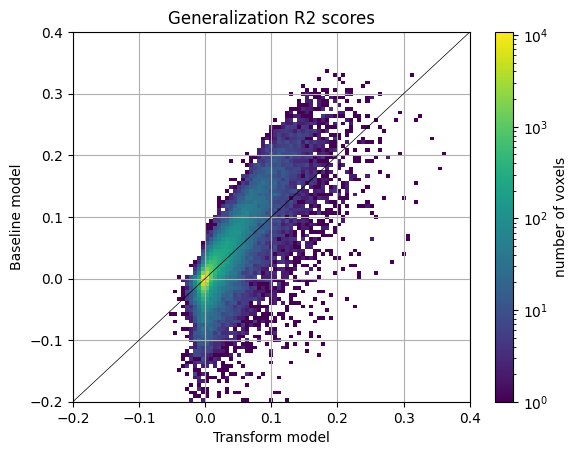

In [ ]:
from voxelwise_tutorials.viz import plot_hist2d

scores_transform = scores_test.cpu().numpy()
ax = plot_hist2d(scores_baseline, scores_transform,vmin=-0.2, vmax=0.4)
ax.set(title='Generalization R2 scores', ylabel='Baseline model',
       xlabel='Transform model')
plt.show()

In [29]:
print(min(scores_baseline),min(scores_transform))
print(max(scores_baseline),max(scores_transform))

-0.06240041852129008 -0.5482551
0.36005074714041596 0.33353955


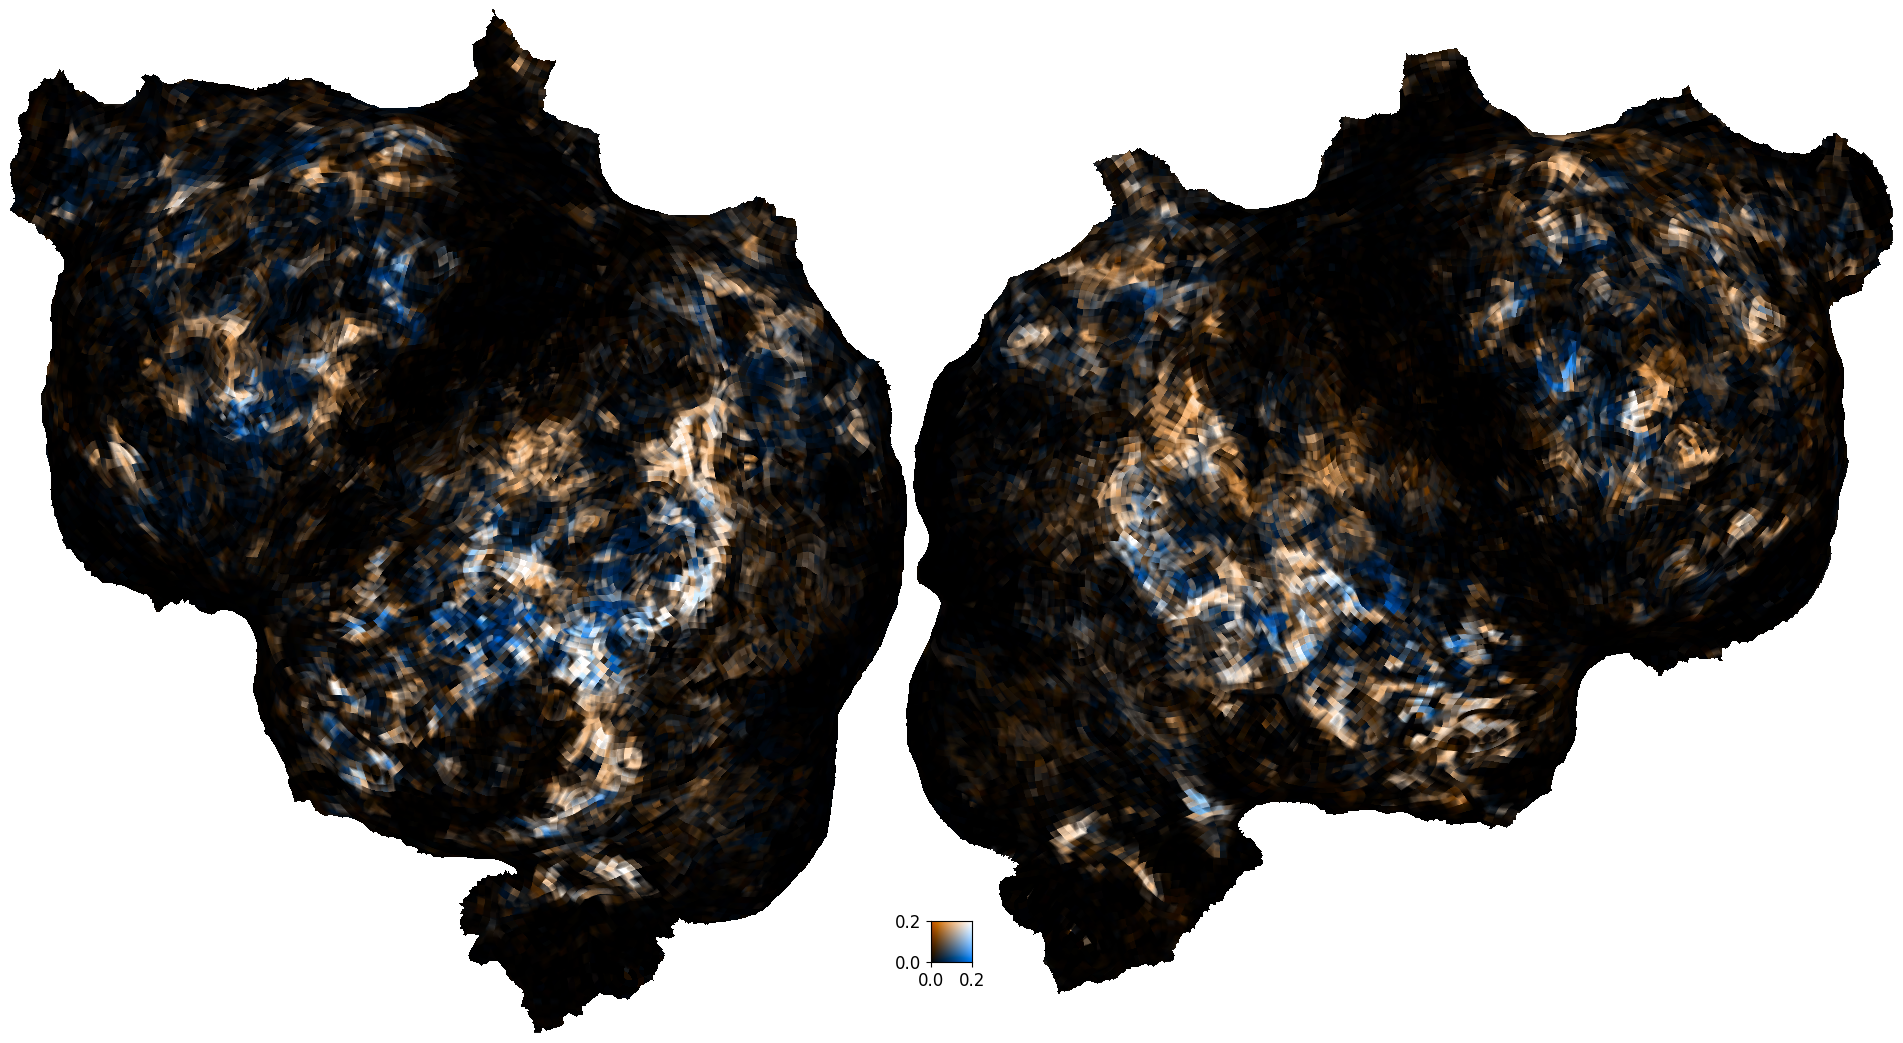

In [10]:
# This creates a 2D Volume object for both of our test datasets for the given
# subject and transform

# You can alter the minimum and maximum values shown on the colorbar and this
# can be done separately for the two different datasets
subject = 'UTS02'
xfm = 'UTS02_auto'
vol_data = cortex.Volume2D(scores_baseline, scores_transform, subject, xfm,
                           #cmap="GreenWhiteBlue_2D",
                           vmin=0,vmin2=0, vmax=0.2, vmax2=0.2
                           )
cortex.quickshow(vol_data, with_rois=False )# with_colorbar=False,
plt.show()